# 07. 時間周波数解析 — STFT・スペクトログラム

**学習目標**: 周波数が **時間とともに変わる** 信号には普通の FFT だけでは足りないことを知り、
**短時間フーリエ変換(STFT)** とスペクトログラムで「いつ・どの周波数が」鳴っているかを見る。
窓幅による時間/周波数分解能のトレードオフを体験する。

## Big Picture / Problem

FFT は信号全体を 1 枚のスペクトルにまとめます。だから「前半は低い音、後半は高い音」でも、
スペクトルには両方の山が出るだけで **時間情報が失われ** ます。
短い窓で区切りながら FFT する STFT がこれを解決します。

$$ X(\tau, \omega) = \int_{-\infty}^{\infty} x(t)\,w(t-\tau)\,e^{-i\omega t}\,dt. $$

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

## Visualization 1 — チャープ(周波数が上がる音)のスペクトログラム

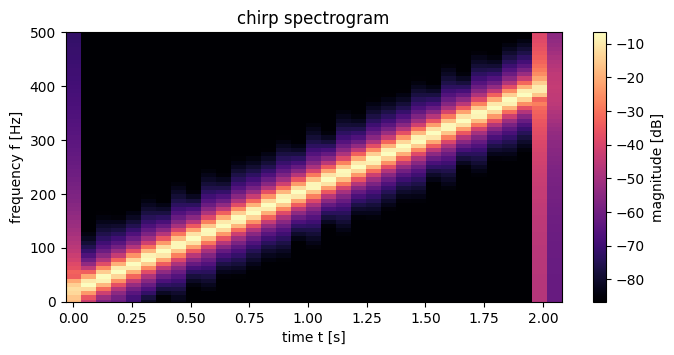

In [2]:
# A linear chirp sweeps low -> high; the spectrogram shows a rising ridge.
fs = 2000.0
t, x = datasets.make_chirp(fs=fs, duration=2.0, f0=20.0, f1=400.0)
f, tt, S = transforms.spectrogram_db(x, fs, nperseg=256)
plotting.plot_spectrogram(f, tt, S, fmax=500, title="chirp spectrogram")
plt.show()

## Visualization 2 — FFT は「いつ」を失う

前半 40 Hz・後半 300 Hz のバースト信号。FFT(左)は 2 本の山を出すだけで順番が分かりません。
スペクトログラム(右)は、どちらが先に鳴ったかをはっきり示します。

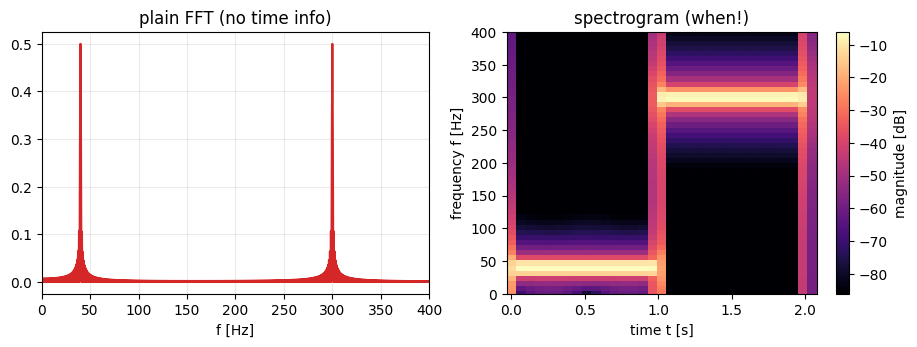

In [3]:
# Two-tone burst: FFT sees both tones; only the spectrogram shows the timing.
fs = 2000.0
t, xb = datasets.make_two_tone_burst(fs=fs, duration=2.0, f_low=40.0, f_high=300.0)
freqs, amp = transforms.amplitude_spectrum(xb, fs)
f2, tt2, S2 = transforms.spectrogram_db(xb, fs, nperseg=256)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(freqs, amp, color="#d62728"); ax[0].set_xlim(0, 400)
ax[0].set_title("plain FFT (no time info)"); ax[0].set_xlabel("f [Hz]"); ax[0].grid(alpha=.25)
plotting.plot_spectrogram(f2, tt2, S2, ax=ax[1], fmax=400, title="spectrogram (when!)")
plt.show()

## Failure Mode — 窓幅のトレードオフ

短い窓 → 時間分解能は高いが周波数はぼやける。長い窓 → 周波数は鋭いが「いつ」が曖昧。
両方同時に鋭くはできません(04 章の不確定性の時間周波数版)。

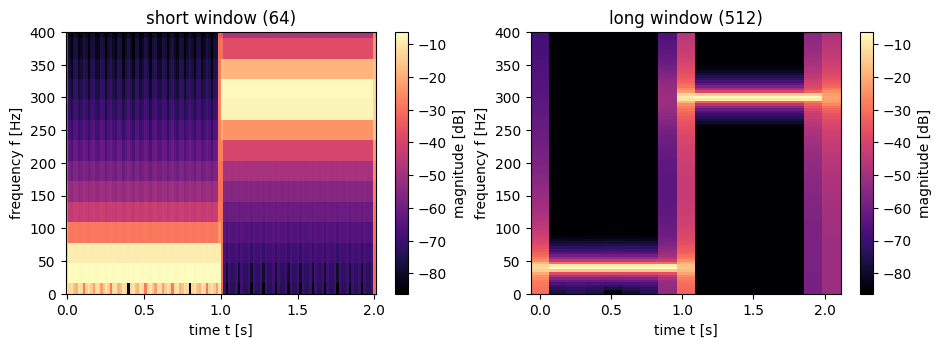

In [4]:
# Short window: sharp in time, blurry in frequency. Long window: the opposite.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, nperseg, label in zip(ax, [64, 512], ["short window (64)", "long window (512)"]):
    f, tt, S = transforms.spectrogram_db(xb, fs, nperseg=nperseg)
    plotting.plot_spectrogram(f, tt, S, ax=a, fmax=400, title=label)
plt.show()

### STFT と wavelet の時間周波数タイル

STFT は一様なタイルで平面を覆う。wavelet は高周波ほど時間分解能を上げる(定 Q)— 同じ
不確定性の予算を、周波数帯ごとに違う配分で使う。

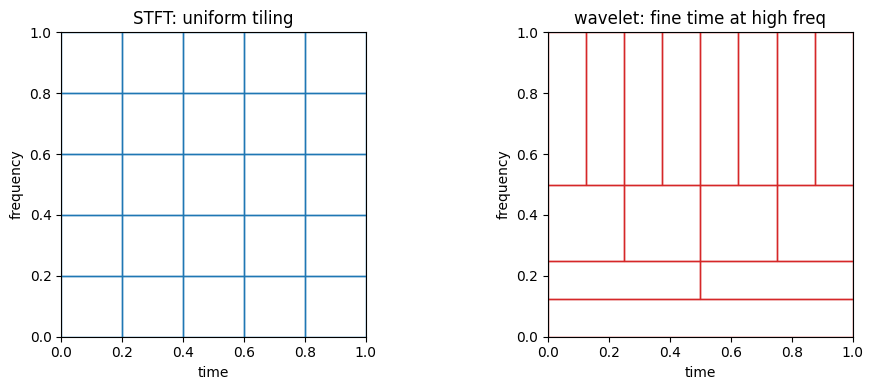

In [5]:
# Heisenberg tiles: STFT tiles uniformly; wavelets give fine time at high freq.
plotting.plot_tf_tiling()
plt.show()

## Application & TODO

応用: 音声・音楽(音符の検出)、機械の異常振動、脳波(EEG)、レーダー。

```{admonition} TODO(発展として追記予定)
:class: tip
- wavelet 変換: 低周波は長い窓・高周波は短い窓と、周波数で分解能を変える
- 連続 wavelet 変換(CWT)のスカログラム(`scipy.signal.cwt` か `pywt`)
- 窓関数の種類(Hann/Gaussian)と再構成(COLA 条件)
- 定 Q 変換(音楽の音階に合わせた対数周波数軸)
```